In [2]:
import numpy as np
import matplotlib.pyplot as plt  
from sklearn.preprocessing import MinMaxScaler, StandardScaler

c:\Users\fpaul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.sparse import csr_matrix, issparse


# Questão 1

### Letra A

In [3]:
dataset = np.loadtxt("artificial1d.csv", delimiter=",", skiprows=1)

In [4]:
x = dataset[:, [0]]

y = dataset[:, [1]]

In [5]:
def plot(x, y, rmse, w):

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = w[0] + w[1] * x_line

    plt.scatter(x, y)       
    plt.plot(x_line, y_line)    

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Regressão Linear (RMSE={rmse:.4f})")

    plt.show()

# Regressão linear via mínimos quadrados ordinários (OLS)

Como visto na aula de regressão linear, dado o seguinte problema:
$$\begin{aligned}
\hat{\boldsymbol{y}} = \boldsymbol{X}\boldsymbol{w}\\
\text{Queremos encontrar:}\\
\hat{\boldsymbol{w}} = \arg\min_{\boldsymbol{w}} ||\boldsymbol{y} - \boldsymbol{X}\boldsymbol{w}||^2
\end{aligned}$$

Como visto, sabemos que:
$$\hat{\boldsymbol{w}} = (\boldsymbol{X}^{\top}\boldsymbol{X})^{-1} \boldsymbol{X}^{\top}\boldsymbol{y}$$

Obtenha um modelo linear para predizer o comprimento de um peixe a partir de sua idade e da temperatura da água. Para isso, encontre o $\hat{\boldsymbol{w}}$ pro dataset `peixe` onde:
$$\boldsymbol{X} = [\mathbf{1}^{\top} \;,\; \mathtt{peixe\underline{}dataset[:,[0,1]}]\\
\boldsymbol{y} = \mathtt{peixe\underline{}dataset[:,[2]]}$$

Sem utilizar estrutura de repetição alguma, calcule a raíz do erro quadrático médio:
$$\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_i^n (\boldsymbol{y} - \hat{\boldsymbol{y}})^2}$$

In [6]:
def regressao_linear(X_input, y):
    X = np.hstack((
        np.ones((X_input.shape[0], 1)),
        X_input
    ))

    w = np.linalg.inv(X.T @ X) @ X.T @ y

    y_hat = X @ w

    rmse = np.sqrt(np.mean((y - y_hat)**2))

    return w, rmse

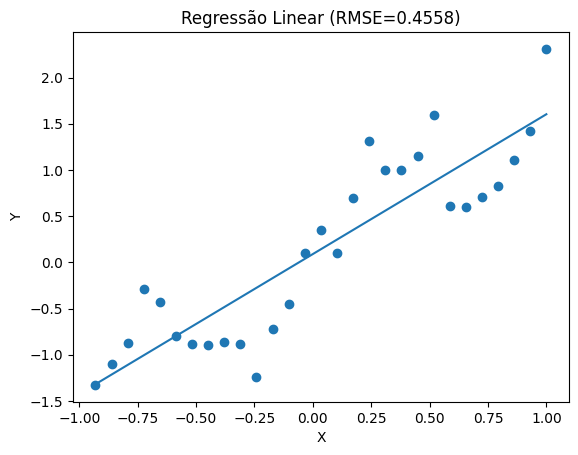

In [7]:
w, rmse = regressao_linear(x, y)
plot(x, y, rmse, w)

### Letra B

# Regressão linear via gradiente descendente (GD)

Sendo $\alpha$ um passo de aprendizagem, $N$ o número de observações disponíveis e $t$ a iteração atual do algoritmo, os parâmetros $\boldsymbol{w}$ podem ser atualizados via algoritmo GD:

$$\boldsymbol{w}(t) = \boldsymbol{w}(t-1) + \alpha \frac{1}{N}\sum_{i=1}^{N} e_i(t-1) \boldsymbol{x}_i,$$
$$\text{em que } e_i(t-1) = y_i - \boldsymbol{w}^{\top}(t-1)\boldsymbol{x}_i$$

Normalize os dados retirando a média e dividindo pelo desvio padrão (entrada e saída). Na predição, desfaça a normalização para computar o RMSE.

In [9]:
# Escreva o código aqui
def regressao_linear_gd(x, y, alpha, iteracoes):

    x_media = x.mean(axis=0, keepdims=True)
    x_std = x.std(axis=0)
    x_norm = (x - x_media) / x_std

    y_media = y.mean()
    y_std = y.std()
    y_norm = (y - y_media) / y_std

    X = np.hstack((np.ones((x_norm.shape[0], 1)), x_norm))

    N = X.shape[0]

    w = np.zeros((X.shape[1], 1))

    for _ in range(iteracoes):

        y_hat = X @ w
        erro = y_norm - y_hat

        gradiente = (X.T @ erro) / N

        w = w + alpha * gradiente

    y_pred_norm = X @ w

    y_pred = y_pred_norm * y_std + y_media

    rmse = np.sqrt(np.mean((y - y_pred) ** 2))

    return w, rmse

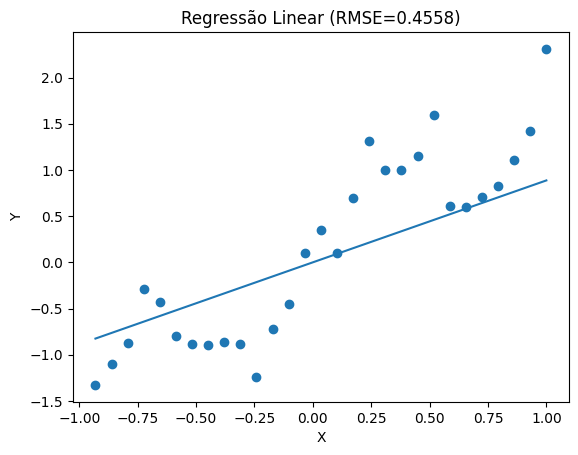

In [10]:
w, rmse = regressao_linear_gd(x=x, y=y, alpha=0.01, iteracoes=1000)
plot(x=x, y=y, rmse=rmse, w=w)

### Letra C

# Regressão linear via gradiente descendente estocástico (SGD)

Sendo $\alpha$ um passo de aprendizagem, $N$ o número de observações disponíveis e $t$ a iteração atual do algoritmo, os parâmetros $\boldsymbol{w}$ podem ser atualizados via algoritmo SGD:

$$\boldsymbol{w}(t) = \boldsymbol{w}(t-1) + \alpha e_i(t-1) \boldsymbol{x}_i,$$
$$\text{em que } e_i(t-1) = y_i - \boldsymbol{w}^{\top}(t-1)\boldsymbol{x}_i$$

Normalize os dados retirando a média e dividindo pelo desvio padrão (entrada e saída). Na predição, desfaça a normalização para computar o RMSE.

In [11]:
def regressao_linear_sgd(x, y, alpha, epocas):

    x_media = x.mean(axis=0)
    x_std = x.std(axis=0)
    x_norm = (x - x_media) / x_std

    y_media = y.mean()
    y_std = y.std()
    y_norm = (y - y_media) / y_std

    X = np.hstack((np.ones((x_norm.shape[0], 1)), x_norm))

    N = X.shape[0]

    w = np.zeros((X.shape[1], 1))

    for _ in range(epocas):

        indices = np.random.permutation(N)

        for i in indices:
            xi = X[i].reshape(-1, 1)
            yi = y_norm[i]

            y_hat = w.T @ xi
            erro = yi - y_hat

            w = w + alpha * erro * xi

    y_pred_norm = X @ w
    y_pred = y_pred_norm * y_std + y_media

    rmse = np.sqrt(np.mean((y - y_pred) ** 2))

    return w, rmse

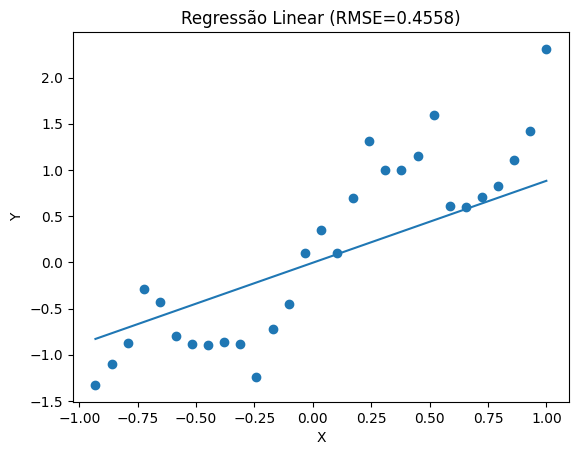

In [12]:
w, rmse = regressao_linear_sgd(x=x, y=y, alpha=0.01, epocas=100)
plot(x=x, y=y, rmse=rmse, w=w)

In [30]:
mse = rmse ** 2
mse

np.float64(0.20772826511511877)

# Questão 2

In [13]:
california = np.loadtxt("california.csv", delimiter=",", skiprows=1)
X = california[:, :8] 
y = california[:, 8]  

### Letra A

In [14]:
def separa_dados(X, y, treino=0.8, seed=42):
    if seed is not None:
        np.random.seed(seed)  

    n = X.shape[0]

    indices = np.random.permutation(n)

    split = int(n * treino)

    train_idx = indices[:split]
    test_idx = indices[split:]

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test

In [15]:
X_train, X_test, y_train, y_test = separa_dados(X, y, treino=0.8, seed=42)

### Letra B

In [16]:
def regressao_polinomial(x, y, grau):

    X = np.ones((x.shape[0], 1))

    for i in range(1, grau + 1):
        X = np.hstack((X, x**i))

    w = np.linalg.inv(X.T @ X) @ X.T @ y

    y_hat = X @ w

    rmse = np.sqrt(np.mean((y - y_hat)**2))

    return w, rmse

In [17]:
graus = []
rmse_treino = []
rmse_teste = []

In [18]:
for grau in range(1, 14):
    w, rmse_train = regressao_polinomial(X_train, y_train, grau)

    X_test_poly = np.ones((X_test.shape[0], 1))
    for i in range(1, grau + 1):
        X_test_poly = np.hstack((X_test_poly, X_test**i))

    y_pred_test = X_test_poly @ w
    rmse_test = np.sqrt(np.mean((y_test - y_pred_test)**2))

    graus.append(grau)
    rmse_treino.append(rmse_train)
    rmse_teste.append(rmse_test)

    print(f"Grau {grau} -> RMSE treino: {rmse_train:.4f} | RMSE teste: {rmse_test:.4f}")

Grau 1 -> RMSE treino: 0.6598 | RMSE teste: 0.7203
Grau 2 -> RMSE treino: 0.6342 | RMSE teste: 0.7135
Grau 3 -> RMSE treino: 0.6122 | RMSE teste: 0.6864
Grau 4 -> RMSE treino: 0.6592 | RMSE teste: 0.9085
Grau 5 -> RMSE treino: 0.7795 | RMSE teste: 1.0321
Grau 6 -> RMSE treino: 1.8067 | RMSE teste: 2.3328
Grau 7 -> RMSE treino: 3.6222 | RMSE teste: 4.4809
Grau 8 -> RMSE treino: 5.7646 | RMSE teste: 13.2376
Grau 9 -> RMSE treino: 29.7426 | RMSE teste: 35.2889
Grau 10 -> RMSE treino: 379.5048 | RMSE teste: 2119.7191
Grau 11 -> RMSE treino: 627.5237 | RMSE teste: 301174.6401
Grau 12 -> RMSE treino: 1399.0108 | RMSE teste: 1702391.6113
Grau 13 -> RMSE treino: 847.7817 | RMSE teste: 3374231.3365


### Letra C

In [19]:
def plot_2(graus, titulo, rmse):
    plt.figure()
    plt.plot(graus, rmse, marker='o')
    plt.title(titulo)
    plt.xlabel("Grau do Polinômio")
    plt.ylabel("RMSE")
    plt.grid()
    plt.show()

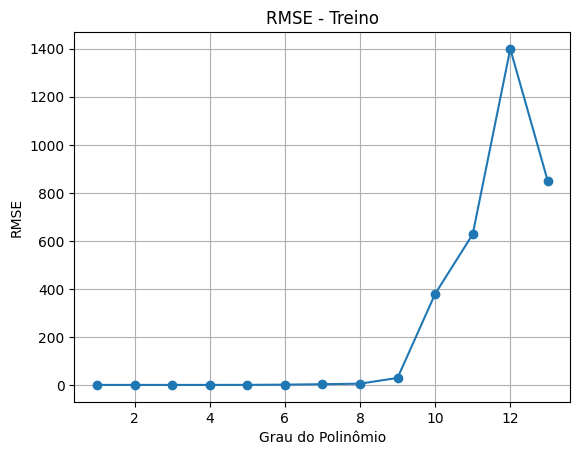

In [20]:
plot_2(graus=graus, titulo="RMSE - Treino", rmse=rmse_treino)

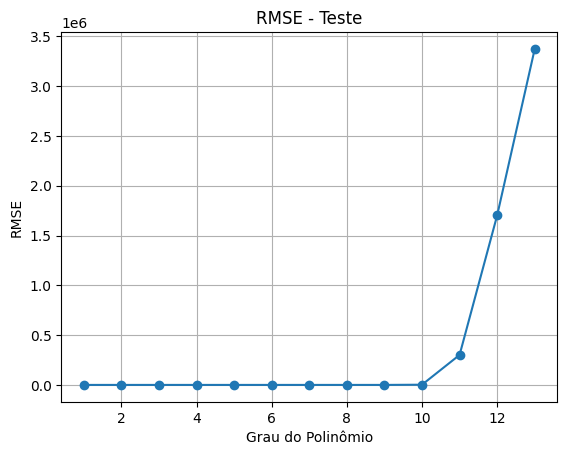

In [21]:
plot_2(graus=graus, titulo="RMSE - Teste", rmse=rmse_teste)

### Letra D

In [22]:
scaler_X = MinMaxScaler()
scaler_y = StandardScaler()

X_train_norm = scaler_X.fit_transform(X_train)
X_test_norm = scaler_X.transform(X_test)

y_train_norm = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_norm = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

In [23]:
def cria_matriz_polinomial(X, grau):
    X_poly = np.ones((X.shape[0], 1))
    
    for i in range(1, grau + 1):
        X_poly = np.hstack((X_poly, X**i))
    
    return X_poly

In [24]:
def regressao_polinomial_l2(X, y, grau, lamb=0.01):
    X_poly = cria_matriz_polinomial(X, grau)

    n_features = X_poly.shape[1]
    I = np.eye(n_features)

    I[0, 0] = 0

    w = np.linalg.inv(X_poly.T @ X_poly + lamb * I) @ X_poly.T @ y

    y_hat = X_poly @ w
    rmse = np.sqrt(np.mean((y - y_hat)**2))

    return w, rmse

In [25]:
graus = []
rmse_treino_l2 = []
rmse_teste_l2 = []

In [26]:
for grau in range(1, 14):
    w, rmse_train = regressao_polinomial_l2(X_train_norm, y_train_norm, grau, lamb=0.01)

    X_test_poly = cria_matriz_polinomial(X_test_norm, grau)
    y_pred_test_norm = X_test_poly @ w

    y_pred_test = scaler_y.inverse_transform(y_pred_test_norm.reshape(-1, 1)).ravel()
    y_test_real = scaler_y.inverse_transform(y_test_norm.reshape(-1, 1)).ravel()

    rmse_test = np.sqrt(np.mean((y_test_real - y_pred_test)**2))

    graus.append(grau)
    rmse_treino_l2.append(rmse_train)
    rmse_teste_l2.append(rmse_test)

    print(f"[L2] Grau {grau} -> RMSE treino: {rmse_train:.4f} | RMSE teste: {rmse_test:.4f}")

[L2] Grau 1 -> RMSE treino: 0.5755 | RMSE teste: 0.7208
[L2] Grau 2 -> RMSE treino: 0.5535 | RMSE teste: 0.7106
[L2] Grau 3 -> RMSE treino: 0.5400 | RMSE teste: 0.6987
[L2] Grau 4 -> RMSE treino: 0.5383 | RMSE teste: 0.6936
[L2] Grau 5 -> RMSE treino: 0.5375 | RMSE teste: 0.6907
[L2] Grau 6 -> RMSE treino: 0.5368 | RMSE teste: 0.6897
[L2] Grau 7 -> RMSE treino: 0.5360 | RMSE teste: 0.6896
[L2] Grau 8 -> RMSE treino: 0.5350 | RMSE teste: 0.6897
[L2] Grau 9 -> RMSE treino: 0.5340 | RMSE teste: 0.6895
[L2] Grau 10 -> RMSE treino: 0.5330 | RMSE teste: 0.6891
[L2] Grau 11 -> RMSE treino: 0.5323 | RMSE teste: 0.6887
[L2] Grau 12 -> RMSE treino: 0.5318 | RMSE teste: 0.6883
[L2] Grau 13 -> RMSE treino: 0.5315 | RMSE teste: 0.6880


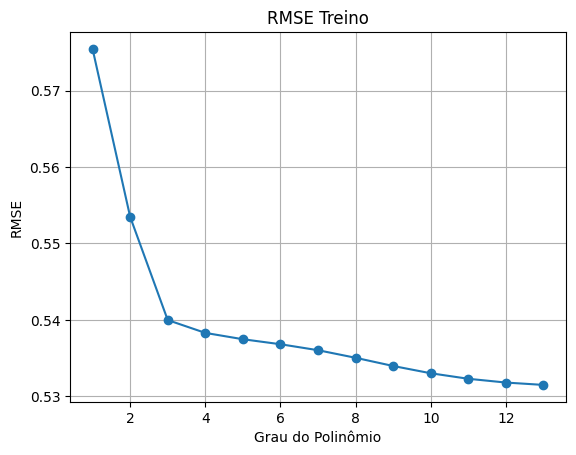

In [27]:
plot_2(graus, "RMSE Treino", rmse_treino_l2)

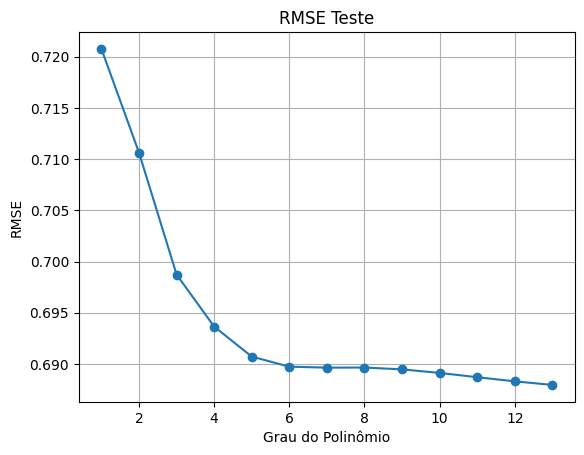

In [28]:
plot_2(graus, "RMSE Teste", rmse_teste_l2)